In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
load_dotenv()
engine = create_engine(f"postgresql://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}"
                       f"@{os.environ['POSTGRES_HOST']}:5433/online_retail")

In [3]:
df = pd.read_sql("""
    SELECT o.customer_id, o.invoice_date
    FROM orders o
    WHERE o.customer_id IS NOT NULL AND NOT o.is_cancelled
""", engine)

In [4]:
df['order_month'] = df['invoice_date'].dt.to_period('M')
df['cohort'] = df.groupby('customer_id')['order_month'].transform('min')
df['period'] = (df['order_month'] - df['cohort']).apply(lambda x: x.n)

sizes = df.groupby(['cohort','period'])['customer_id'].nunique().unstack(0)
retention = sizes.divide(sizes.iloc[0], axis=1).T

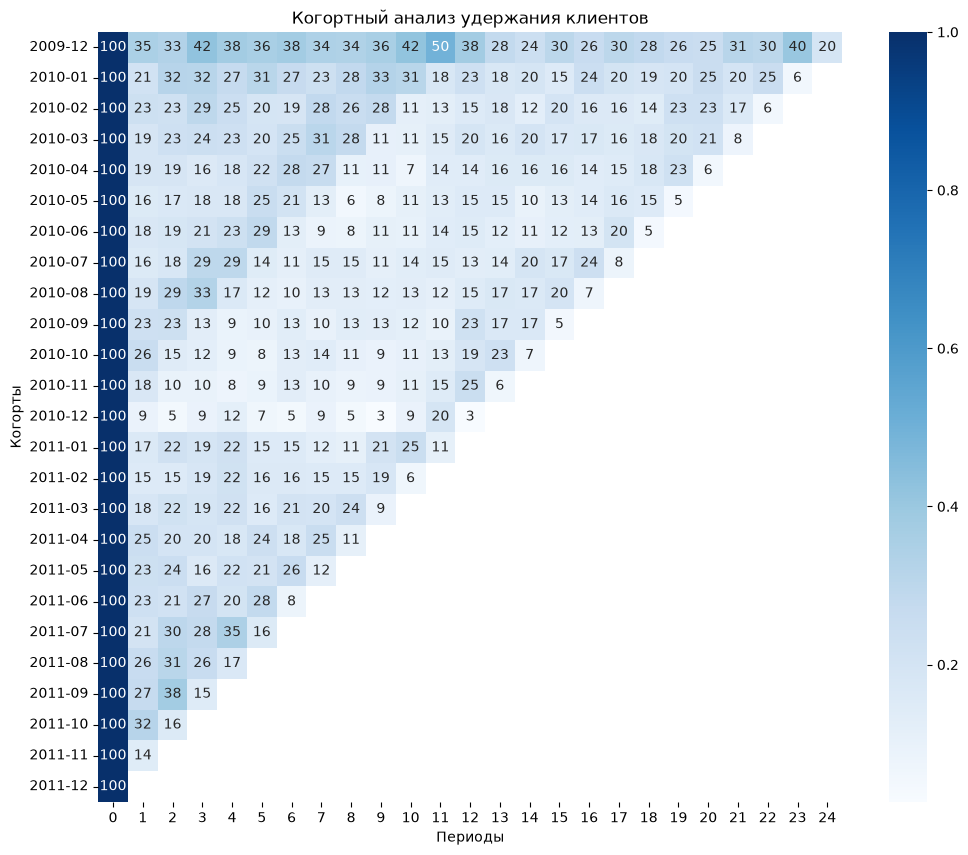

In [5]:
plt.figure(figsize=(12, 10))

ax = sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues')

for t in ax.texts:
    t.set_text(t.get_text().replace("%", ""))

ax.set(xlabel="Периоды", ylabel="Когорты", title="Когортный анализ удержания клиентов")
plt.show()